In [14]:
import argparse
from pathlib import Path
import sys

import torch 

import numpy as np
import pandas as pd
import yaml
from sklearn.datasets import fetch_openml
from src.io.read_file import merged_specs
from src.data.tabular import (
    create_dataloader,
    get_num_cat_columns,
    preprocess_features,
    remove_constant_columns,
    remove_duplicate_rows,
    remove_identifier_columns,
    remove_missing_label,
    split_data,
)

from sklearn.decomposition import PCA
from src.models.VAE import VariationalAutoencoder
from src.models.AE import Autoencoder
from src.hpo.vae_autoencoder_hpo import create_study_vae
from src.hpo.autoencoder_hpo import create_study_ae

In [2]:
specs = merged_specs(Path("../databank/tabular_datasets.yaml"))
names = list(specs)

In [3]:
"mfeat_karhunen" in names
spec = specs["mfeat_karhunen"]

In [4]:
dataset = fetch_openml(data_id=spec["data_id"], as_frame=True, parser="auto")

X, y = dataset.data.copy(), dataset.target.copy()
y = pd.Series(y, index=X.index)
print("original Feature shape", X.shape, y.shape, type(X), type(y))


original Feature shape (2000, 64) (2000,) <class 'pandas.DataFrame'> <class 'pandas.Series'>


In [5]:
X, y, duplicate_count = remove_duplicate_rows(X, y)
X, y, missing_label_count = remove_missing_label(X, y)
X = remove_identifier_columns(X, spec.get("identifier_columns", []))

print("Shape after removing identifiers", X.shape, y.shape)

Shape after removing identifiers (1994, 64) (1994,)


In [6]:
expected_features = spec.get("expected_features")
if expected_features is not None and X.shape[1] != expected_features:
    raise AssertionError(
        f"expected {expected_features} predictors, received {X.shape[1]}"
    )

X, constant_columns = remove_constant_columns(X)

print("shape after removing constant columns", X.shape, y.shape)

shape after removing constant columns (1994, 64) (1994,)


In [7]:
X, numeric, categorical = get_num_cat_columns(
    X,
    categorical_columns=spec.get("manual_categorical_columns", []),
    numeric_columns=spec.get("manual_numeric_columns", []),
)

print("cleaned shape", X.shape, y.shape)

cleaned shape (1994, 64) (1994,)


In [13]:
X_train, X_val, X_test, y_train, y_val, y_test, encoder = split_data(X, y)
X_train, X_val, X_test = preprocess_features(
    X_train, X_val, X_test, numeric, categorical
)

X_train_tensor = torch.from_numpy(X_train).float()
y_train_tensor = torch.from_numpy(y_train)

X_val_tensor   = torch.from_numpy(X_val).float()
y_val_tensor = torch.from_numpy(y_val)

X_test_tensor  = torch.from_numpy(X_test).float()



X_train_val_tensor = torch.cat([X_train_tensor, X_val_tensor], dim=0)
y_train_val_tensor = torch.cat([y_train_tensor, y_val_tensor], dim=0)

X_train_val = X_train_val_tensor.detach().cpu().numpy()
y_train_val = y_train_val_tensor.detach().cpu().numpy()


print("split shape: X_train, X_val, X_test, X_train_val ",X_train.shape, X_val.shape, X_test.shape, X_train_val.shape)


split shape: X_train, X_val, X_test, X_train_val  (1196, 64) (399, 64) (399, 64) (1595, 64)


In [10]:

study_ae = create_study_ae(
    X_train_tensor,
    X_val_tensor,
    n_epochs=100,
    bottleneck_dim=2,
    n_trials=20,
    study_name="autoencoder_HPO_mfeat_analysis"
)

print(len(study_ae.trials))
print(study_ae.best_value)
print(study_ae.best_params)

[I 2026-09-13 11:25:07,765] A new study created in memory with name: autoencoder_HPO_mfeat_analysis
Best trial: 0. Best value: 1.01723:   5%|▌         | 1/20 [00:12<03:59, 12.61s/it]

[I 2026-09-13 11:25:20,337] Trial 0 finished with value: 1.0172330141067505 and parameters: {'lr': 0.0001329291894316216, 'depth': 3, 'activation': 'ReLU', 'n_epochs': 100}. Best is trial 0 with value: 1.0172330141067505.


Best trial: 1. Best value: 0.764477:  10%|█         | 2/20 [00:14<01:50,  6.16s/it]

[I 2026-09-13 11:25:22,028] Trial 1 finished with value: 0.7644765973091125 and parameters: {'lr': 0.003967605077052989, 'depth': 2, 'activation': 'GELU', 'n_epochs': 150}. Best is trial 1 with value: 0.7644765973091125.


Best trial: 1. Best value: 0.764477:  15%|█▌        | 3/20 [00:15<01:09,  4.09s/it]

...

[I 2026-09-13 11:25:32,690] Trial 12 finished with value: 0.7780381441116333 and parameters: {'lr': 0.008426745404431429, 'depth': 2, 'activation': 'Tanh', 'n_epochs': 200}. Best is trial 1 with value: 0.7644765973091125.
[I 2026-09-13 11:25:32,712] Trial 13 pruned. 


Best trial: 14. Best value: 0.7512:  80%|████████  | 16/20 [00:26<00:03,  1.19it/s] 

[I 2026-09-13 11:25:34,211] Trial 14 finished with value: 0.751200258731842 and parameters: {'lr': 0.002969616660570543, 'depth': 2, 'activation': 'GELU', 'n_epochs': 200}. Best is trial 14 with value: 0.751200258731842.
[I 2026-09-13 11:25:34,254] Trial 15 pruned. 
[I 2026-09-13 11:25:34,298] Trial 16 pruned. 


Best trial: 17. Best value: 0.725982: 100%|██████████| 20/20 [00:28<00:00,  1.42s/it]

[I 2026-09-13 11:25:35,994] Trial 17 finished with value: 0.7259819507598877 and parameters: {'lr': 0.0034752685500731954, 'depth': 2, 'activation': 'GELU', 'n_epochs': 250}. Best is trial 17 with value: 0.7259819507598877.
[I 2026-09-13 11:25:36,045] Trial 18 pruned. 
[I 2026-09-13 11:25:36,076] Trial 19 pruned. 
20
0.7259819507598877
{'lr': 0.0034752685500731954, 'depth': 2, 'activation': 'GELU', 'n_epochs': 250}


In [11]:

study_vae = create_study_vae(
    X_train_tensor,
    X_val_tensor,
    n_epochs=100,
    bottleneck_dim=32,
    n_trials=20,
    study_name="vae_hpo_study"
)

print(len(study_vae.trials))
print(study_vae.best_value)
print(study_vae.best_params)

[I 2026-09-13 11:25:53,213] A new study created in memory with name: vae_hpo_study
Best trial: 0. Best value: 0.899465:   5%|▌         | 1/20 [00:06<01:54,  6.04s/it]

[I 2026-09-13 11:25:59,245] Trial 0 finished with value: 0.8994646072387695 and parameters: {'lr': 0.0001329291894316216, 'depth': 3, 'activation': 'ReLU', 'beta': 0.12389490049257872, 'n_epochs': 450}. Best is trial 0 with value: 0.8994646072387695.


Best trial: 0. Best value: 0.899465:  10%|█         | 2/20 [00:07<01:03,  3.54s/it]

[I 2026-09-13 11:26:01,038] Trial 1 finished with value: 0.94095778465271 and parameters: {'lr': 0.0006358358856676254, 'depth': 3, 'activation': 'LeakyReLU', 'beta': 0.19556651891602772, 'n_epochs': 150}. Best is trial 0 with value: 0.8994646072387695.


Best trial: 0. Best value: 0.899465:  15%|█▌        | 3/20 [00:08<00:39,  2.35s/it]

...

[I 2026-09-13 11:26:22,027] Trial 14 pruned. 
[I 2026-09-13 11:26:22,071] Trial 15 pruned. 
[I 2026-09-13 11:26:22,112] Trial 16 pruned. 


Best trial: 11. Best value: 0.603735:  90%|█████████ | 18/20 [00:29<00:02,  1.23s/it]

[I 2026-09-13 11:26:22,683] Trial 17 finished with value: 1.0091947317123413 and parameters: {'lr': 0.0045256153950211314, 'depth': 3, 'activation': 'LeakyReLU', 'beta': 0.5499656510813108, 'n_epochs': 350}. Best is trial 11 with value: 0.6037354469299316.
[I 2026-09-13 11:26:22,725] Trial 18 pruned. 


Best trial: 11. Best value: 0.603735: 100%|██████████| 20/20 [00:31<00:00,  1.58s/it]

[I 2026-09-13 11:26:24,800] Trial 19 pruned. 
20
0.6037354469299316
{'lr': 0.0013338806107692806, 'depth': 3, 'activation': 'LeakyReLU', 'beta': 0.10834833350816106, 'n_epochs': 400}


In [15]:
from src.hpo.hidden_dims import build_hidden_dims_geo
from src.metrics.knn import compute_knn_score, find_best_neighbors
from src.training.train import train_final_model
from src.training.train_vae import train_final_model_vae
import torch.nn as nn


best_params_ae = study_ae.best_params
best_params_vae = study_vae.best_params
activation_functions = {
    "ReLU": nn.ReLU,
    "LeakyReLU": nn.LeakyReLU,
    "GELU": nn.GELU,
    "Tanh": nn.Tanh,
}

input_dim = X_train_val_tensor.shape[1]
bottleneck_range = [1,2,4,8,16,24,30,38,45,50,54,62]

epochs = 400

pca_errors= []
ae_errors = []
vae_errors = []

ae_knn = []
pca_knn = []
vae_knn = []

ae_total_loss = []
ae_recon_loss = []
ae_kl_loss =[]

vae_total_loss = []
vae_recon_loss = []
vae_kl_loss =[]


best_neighbors, best_val_score = find_best_neighbors(
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val
)

print("Best neighbors:", best_neighbors)
print("Validation accuracy:", best_val_score)


for k in bottleneck_range:
    torch.manual_seed(42)
    np.random.seed(42)

    final_hidden_dims_ae = build_hidden_dims_geo(
        input_dim,
        latent_dim=k,
        depth = best_params_ae["depth"]
    )

    final_hidden_dims_vae = build_hidden_dims_geo(
            input_dim,
            latent_dim=k,
            depth=best_params_vae["depth"]
    )

    # --------------PCA-----------------
    pca = PCA(n_components=k)
    X_train_reduced_pca = pca.fit_transform(X_train_val)
    X_train_recon_pca = pca.inverse_transform(X_train_reduced_pca)

    X_test_reduced_pca = pca.transform(X_test)

    pca_knn_accuracy = compute_knn_score(
        X_train = X_train_reduced_pca,
        y_train = y_train_val,
        X_test = X_test_reduced_pca,
        y_test = y_test,
        n_neighbors=best_neighbors
    )

    pca_errors.append(np.mean((X_train_val - X_train_recon_pca) ** 2))
    pca_knn.append(pca_knn_accuracy)

    # --------------AE-----------------
    final_ae = Autoencoder(
        n_features=input_dim,
        bottleneck_dim=k,
        hidden_dims_list=final_hidden_dims_ae,
        non_linear=True,
        non_linear_function=activation_functions[
            best_params_ae["activation"]
        ]
    )

    train_loss_ae, test_loss_ae, z_train_val_ae, z_test_ae  = train_final_model(
            final_model=final_ae,
            X_train_val_tensor=X_train_val_tensor,
            X_test_tensor=X_test_tensor, 
            best_params=best_params_ae, 
            epochs=400
        )

    z_train_val_ae = z_train_val_ae.cpu().numpy()
    z_test_ae = z_test_ae.cpu().numpy()

    ae_knn_accuracy = compute_knn_score(
            X_train=z_train_val_ae,
            y_train=y_train_val,
            X_test=z_test_ae,
            y_test=y_test,
            n_neighbors=best_neighbors
    )

    ae_knn.append(ae_knn_accuracy)
    ae_recon_loss.append(train_loss_ae)


    # --------------VAE-----------------
    final_vae = VariationalAutoencoder(
            n_features=input_dim,
            bottleneck_dim=k,
            hidden_dims_list=final_hidden_dims_vae,
            non_linear_function=activation_functions[best_params_vae["activation"]]
    )

    train_loss_vae, test_loss_vae, recon_loss_vae, kl_loss_vae, mu_train_val_vae, mu_test_vae = train_final_model_vae(
            final_model=final_vae,
            X_train_val_tensor=X_train_val_tensor,
            X_test_tensor=X_test_tensor,
            best_params=best_params_vae,
            epochs=400
    )

    mu_train_val_vae = mu_train_val_vae.cpu().numpy()
    mu_test_vae = mu_test_vae.cpu().numpy()

    vae_knn_accuracy = compute_knn_score(
            X_train=mu_train_val_vae,
            y_train=y_train_val,
            X_test=mu_test_vae,
            y_test=y_test,
            n_neighbors=best_neighbors
    )

    vae_knn.append(vae_knn_accuracy)
    vae_total_loss.append(train_loss_vae)
    vae_recon_loss.append(recon_loss_vae)
    vae_kl_loss.append(kl_loss_vae)
    
    print(
        f"k={k:>3} "
        f"AE KNN={ae_knn_accuracy:.4f} "
        f"AE Loss={train_loss_ae:.4f} "
        f"Test Loss AE ={test_loss_ae:.4f} "
        f"VAE KNN={vae_knn_accuracy:.4f} "
        f"VAE Loss={train_loss_vae:.4f} "
        f"Test Loss VAE={test_loss_vae:.4f} "
    )

Best neighbors: 5
Validation accuracy: 0.9523809523809523
k=  1 AE KNN=0.3985 AE Loss=0.8195 Test Loss AE =0.8398 VAE KNN=0.0777 VAE Loss=1.0022 Test Loss VAE=1.0059 
k=  2 AE KNN=0.7419 AE Loss=0.6900 Test Loss AE =0.7288 VAE KNN=0.1729 VAE Loss=0.9567 Test Loss VAE=0.9671 
k=  4 AE KNN=0.8822 AE Loss=0.5772 Test Loss AE =0.6257 VAE KNN=0.4486 VAE Loss=0.8503 Test Loss VAE=0.8710 
k=  8 AE KNN=0.8997 AE Loss=0.4785 Test Loss AE =0.5255 VAE KNN=0.5840 VAE Loss=0.7403 Test Loss VAE=0.7703 
k= 16 AE KNN=0.9273 AE Loss=0.3864 Test Loss AE =0.4427 VAE KNN=0.6566 VAE Loss=0.6622 Test Loss VAE=0.6949 
k= 24 AE KNN=0.9248 AE Loss=0.3391 Test Loss AE =0.3901 VAE KNN=0.5990 VAE Loss=0.5696 Test Loss VAE=0.6187 
k= 30 AE KNN=0.9524 AE Loss=0.3219 Test Loss AE =0.3715 VAE KNN=0.6692 VAE Loss=0.5580 Test Loss VAE=0.6070 
k= 38 AE KNN=0.9549 AE Loss=0.2749 Test Loss AE =0.3240 VAE KNN=0.7444 VAE Loss=0.5277 Test Loss VAE=0.5867 
k= 45 AE KNN=0.9574 AE Loss=0.2575 Test Loss AE =0.3096 VAE KNN=0.7318

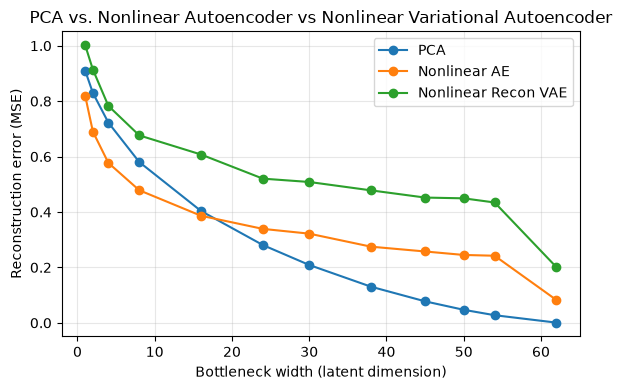

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.plot(bottleneck_range, pca_errors, marker="o", label="PCA")
plt.plot(bottleneck_range, ae_recon_loss, marker="o", label="Nonlinear AE")
plt.plot(bottleneck_range, vae_recon_loss, marker="o", label="Nonlinear Recon VAE")
plt.xlabel("Bottleneck width (latent dimension)")
plt.ylabel("Reconstruction error (MSE)")
plt.title("PCA vs. Nonlinear Autoencoder vs Nonlinear Variational Autoencoder")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

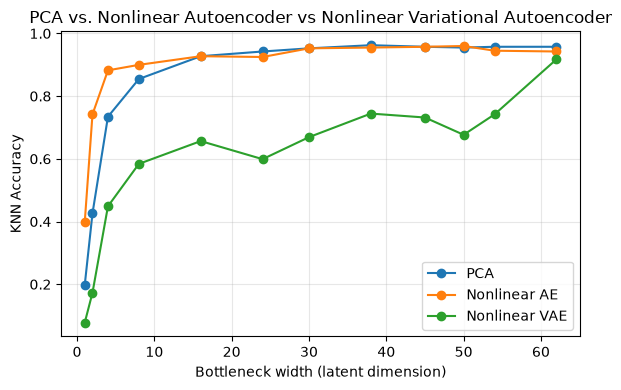

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.plot(bottleneck_range, pca_knn, marker="o", label="PCA")
plt.plot(bottleneck_range, ae_knn, marker="o", label="Nonlinear AE")
plt.plot(bottleneck_range, vae_knn, marker="o", label="Nonlinear VAE")
plt.xlabel("Bottleneck width (latent dimension)")
plt.ylabel("KNN Accuracy")
plt.title("PCA vs. Nonlinear Autoencoder vs Nonlinear Variational Autoencoder")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()